# Validación de la meteorología ERA5-Land

Este notebook comprueba el cubo meteorológico diario 2018-12-01 a 2023-12-31 y visualiza una variable sin generar archivos PNG.

In [7]:
import matplotlib.pyplot as plt
import xarray as xr

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

from src.config import ERA5_DAILY_PATH, METEOROLOGY_CUBE_PATH

DAILY_PATH = ERA5_DAILY_PATH
CUBE_PATH = METEOROLOGY_CUBE_PATH
FECHA = "2022-07-15"
VARIABLE = "temperature_max_12_18h"

In [8]:
daily = xr.open_dataset(DAILY_PATH)
meteo = xr.open_dataset(CUBE_PATH)

print("Periodo diario:", str(daily.time.min().values)[:10], "a", str(daily.time.max().values)[:10])
print("Periodo del cubo:", str(meteo.time.min().values)[:10], "a", str(meteo.time.max().values)[:10])
print("Variables:", list(daily.data_vars))
print("Dimensiones del cubo:", dict(meteo.sizes))

Periodo diario: 2018-12-01 a 2023-11-30
Periodo del cubo: 2018-12-01 a 2023-11-26
Variables: ['temperature_mean', 'temperature_min', 'temperature_max', 'temperature_max_12_18h', 'relative_humidity_mean', 'relative_humidity_min', 'relative_humidity_min_12_18h', 'wind_speed_mean', 'wind_speed_max', 'wind_speed_max_12_18h', 'precipitation_sum', 'precipitation_sum_3d', 'precipitation_sum_7d', 'precipitation_sum_14d', 'precipitation_sum_30d', 'temperature_mean_7d', 'relative_humidity_mean_7d', 'consecutive_dry_days']
Dimensiones del cubo: {'y': 225, 'x': 203, 'time': 1822}


In [9]:
active = meteo["is_galicia"] == 1
valid = meteo[VARIABLE].notnull() & active

print(f"Celdas activas: {int(active.sum())}")
print(f"Valores válidos de {VARIABLE}: {int(valid.sum())}")
print(f"Cobertura sobre celdas activas: {float(valid.sum() / active.sum() / meteo.sizes['time'] * 100):.2f}%")
assert meteo.sizes["time"] > 0
assert daily.sizes["time"] >= meteo.sizes["time"]

Celdas activas: 29601
Valores válidos de temperature_max_12_18h: 53933022
Cobertura sobre celdas activas: 100.00%


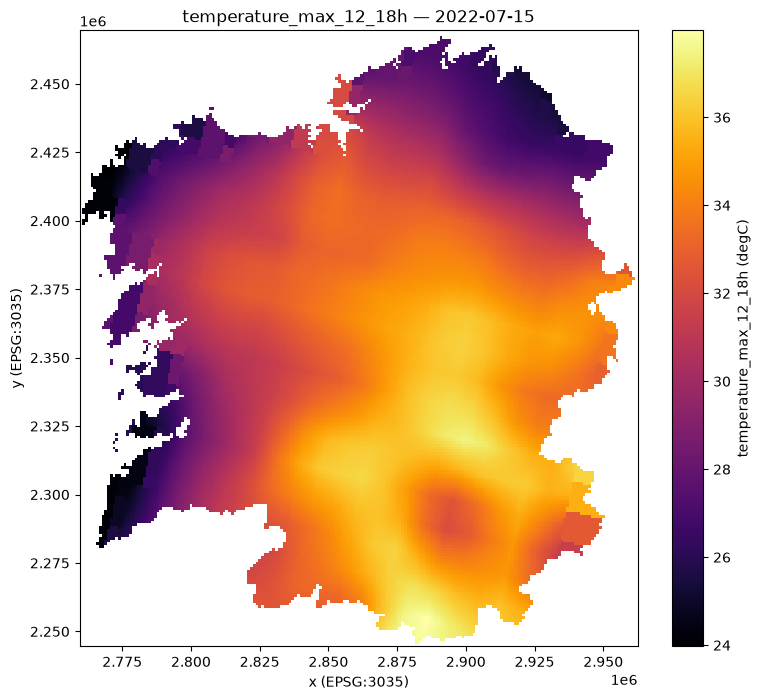

In [10]:
units = meteo[VARIABLE].attrs.get("units", "")
layer = meteo[VARIABLE].sel(time=FECHA).where(active)

fig, ax = plt.subplots(figsize=(9, 8), facecolor="white")
layer.plot(ax=ax, cmap="inferno", cbar_kwargs={"label": f"{VARIABLE} ({units})"})
ax.set_title(f"{VARIABLE} — {FECHA}")
ax.set_xlabel("x (EPSG:3035)")
ax.set_ylabel("y (EPSG:3035)")
ax.set_facecolor("white")
plt.show()

In [11]:
daily.close()
meteo.close()

## Validación visual del contrato final

Esta celda comprueba que la variable existe en el cubo final y la representa sobre la máscara de Galicia con fondo blanco.

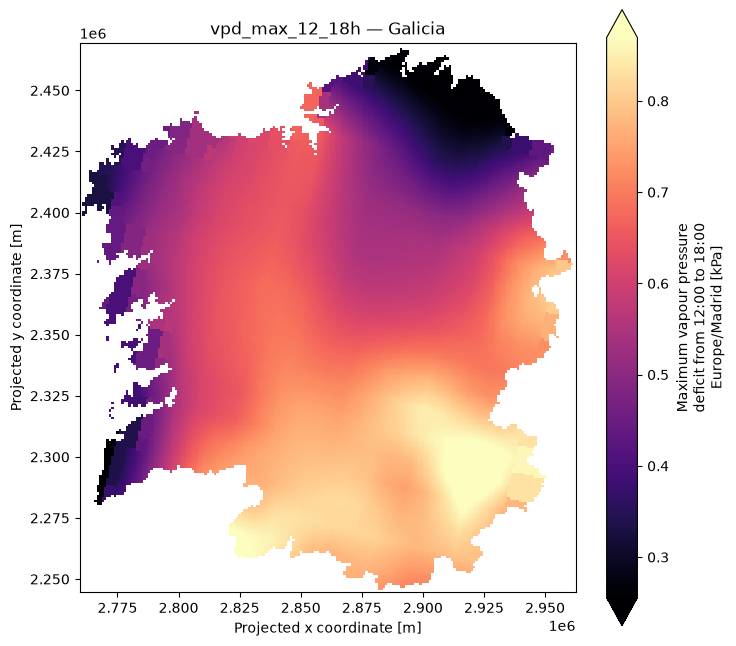

In [13]:
import matplotlib.pyplot as plt
import xarray as xr
from src.config import DATACUBE_PATH

variable = "vpd_max_12_18h"
with xr.open_dataset(DATACUBE_PATH) as cube:
    if variable not in cube:
        available = [name for name in cube.data_vars if "12_18h" in name or name.startswith("vpd")]
        print(
            f"{variable} todavía no está en el cubo canónico. "
            "La reconstrucción final debe terminar antes de validarla."
        )
        print("Variables relacionadas disponibles:", available)
    else:
        data = cube[variable].isel(time=0).where(cube["is_galicia"] == 1)
        assert data.notnull().any(), f"{variable} no contiene valores válidos"
        fig, ax = plt.subplots(figsize=(8, 8), facecolor="white")
        data.plot(ax=ax, cmap="magma", robust=True, add_colorbar=True)
        ax.set(title=f"{variable} — Galicia", facecolor="white")
        ax.set_aspect("equal")
        plt.show()